# Proyecto Final — Series de Tiempo y Panel Data
**Ulises Salinas Lopez | A00814787**

Este notebook complementa el análisis econométrico realizado en R.
Se aplican dos herramientas adicionales:

1. **ARIMA + GARCH:** Modelos de series de tiempo para pronosticar el precio
   de cierre de los 7 activos más prometedores del portafolio a 7 días hábiles.
   Los resultados alimentan la decisión de pesos finales del portafolio.

2. **Panel Data (PanelOLS con efectos fijos):** Modelo de datos de panel
   que analiza la relación entre variables fundamentales (Revenue,
   Operating Margin, Debt-to-Equity) y el Net Income de las empresas
   del portafolio a través del tiempo.

## Paso 1 — Instalación de librerías

Se instalan las librerías necesarias para los modelos de series de tiempo
y datos de panel. `pmdarima` permite encontrar automáticamente el mejor
orden ARIMA. `arch` implementa el modelo GARCH para estimar volatilidad.
`linearmodels` provee el modelo de datos de panel con efectos fijos.

In [13]:
!pip install yfinance pandas numpy matplotlib seaborn statsmodels linearmodels pmdarima arch -q

## Paso 2 — Importación de librerías

Se importan todas las librerías necesarias para el análisis completo.
`yfinance` descarga los datos históricos de Yahoo Finance. `auto_arima`
selecciona automáticamente el orden óptimo (p,d,q) del modelo ARIMA
usando criterios de información (AIC/BIC). `arch_model` estima la
volatilidad condicional mediante GARCH(1,1).

In [14]:
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
import seaborn as sns
from pmdarima import auto_arima
from arch import arch_model
from statsmodels.regression.linear_model import OLS
from statsmodels.tools import add_constant
from linearmodels.panel import PanelOLS
import warnings
warnings.filterwarnings('ignore')

print('Librerías cargadas correctamente.')

Librerías cargadas correctamente.


---
# PARTE 1 — Series de Tiempo: ARIMA + GARCH

Se aplica el modelo ARIMA + GARCH a los **7 activos más prometedores**
del portafolio, seleccionados con base en su beta vs SPY, significancia
estadística en el modelo múltiple y niveles de VIF aceptables identificados
en el análisis de R:

**TSLA, NVDA, AMZN, MSFT, META, AAPL, QQQ**

Para cada activo se genera:
- Modelo ARIMA con orden óptimo seleccionado automáticamente
- Ajuste GARCH(1,1) sobre los residuos para estimar volatilidad
- Pronóstico de precio a **7 días hábiles** con intervalo de confianza al 95%
- Gráfica histórica + forecast
- Decisión de inversión automática (COMPRAR / MANTENER / VENDER EN CORTO)

## Paso 3 — Función ARIMA + GARCH por activo

Se define una función reutilizable que recibe el ticker de un activo
y ejecuta el pipeline completo: descarga de datos, ajuste ARIMA,
corrección por volatilidad GARCH, pronóstico a 7 días y decisión
de inversión. Esto evita repetir código para cada uno de los 7 activos.

In [15]:
def arima_forecast(ticker, start='2022-01-01', n_days=7):
    """
    Ejecuta el pipeline ARIMA + GARCH para un activo dado.
    Retorna un diccionario con los resultados del forecast.
    """
    print(f'\n{"="*60}')
    print(f'  ARIMA + GARCH — {ticker}')
    print(f'{"="*60}')

    # --- Descarga de datos ---
    df_stock = yf.download(ticker, start=start, progress=False)
    if isinstance(df_stock.columns, pd.MultiIndex):
        df_stock.columns = df_stock.columns.droplevel(1)
    df = df_stock[['Close']].copy().dropna()
    print(f'Observaciones descargadas: {len(df)}')
    print(f'Período: {df.index[0].date()} → {df.index[-1].date()}')

    # --- Modelo ARIMA ---
    # auto_arima selecciona automáticamente el mejor orden (p,d,q)
    # minimizando el AIC. seasonal=False porque trabajamos con
    # retornos diarios sin estacionalidad anual relevante.
    print('\nAjustando modelo ARIMA...')
    arima_model = auto_arima(
        df['Close'],
        seasonal=False,
        stepwise=True,
        max_p=5, max_q=5, max_d=2,
        trace=False,
        error_action='ignore',
        suppress_warnings=True
    )
    arima_model.fit(df['Close'])
    print(f'Mejor orden ARIMA encontrado: {arima_model.order}')

    # --- Forecast iterativo con ajuste GARCH ---
    # Se pronostica día a día (rolling forecast) y se actualiza el modelo
    # con cada predicción. GARCH(1,1) ajusta el intervalo de confianza
    # usando la volatilidad condicional estimada sobre los residuos.
    print(f'\nGenerando forecast para los próximos {n_days} días hábiles...')
    last_date = df.index[-1]
    future_dates = pd.date_range(
        start=last_date + pd.Timedelta(days=1),
        periods=n_days, freq='B'
    )

    future_preds, future_lower, future_upper = [], [], []
    current_series = df['Close'].copy()

    for i in range(n_days):
        pred_mean = arima_model.predict(n_periods=1).item()
        resid = arima_model.resid()
        adjustment, vol = 0.0, 0.0
        if len(resid) > 30:
            garch = arch_model(resid, mean='Zero', vol='Garch',
                               p=1, q=1, dist='Normal')
            garch_fit = garch.fit(disp='off', show_warning=False)
            adjustment = garch_fit.forecast(horizon=1).mean.values[-1, 0]
            vol = np.sqrt(garch_fit.forecast(horizon=1).variance.values[-1, 0])
        pred = pred_mean + adjustment
        future_preds.append(round(pred, 2))
        future_lower.append(round(pred - 1.96 * vol, 2))
        future_upper.append(round(pred + 1.96 * vol, 2))
        current_series[future_dates[i]] = pred
        arima_model.fit(current_series)

    # --- Tabla de resultados ---
    forecast_df = pd.DataFrame({
        'Fecha': future_dates.strftime('%Y-%m-%d (%a)'),
        'Precio Predicho': future_preds,
        'Límite Inferior (95% CI)': future_lower,
        'Límite Superior (95% CI)': future_upper
    })
    print(f'\n=== FORECAST — {ticker} (próximos {n_days} días hábiles) ===')
    print(forecast_df.to_string(index=False))

    # --- Gráfica histórica + forecast ---
    # Se muestra solo el último año de datos históricos para que la
    # gráfica sea legible junto con el forecast de 7 días.
    hist_plot = df['Close'].last('365D')
    plt.figure(figsize=(14, 5))
    plt.plot(hist_plot, label='Histórico (último año)', color='steelblue')
    plt.plot(future_dates, future_preds,
             label='Forecast central', marker='o',
             linestyle='--', color='red')
    plt.fill_between(future_dates, future_lower, future_upper,
                     color='red', alpha=0.2, label='IC 95%')
    plt.title(f'Forecast ARIMA{arima_model.order} + GARCH — {ticker}')
    plt.xlabel('Fecha')
    plt.ylabel('Precio de cierre (USD)')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

    # --- Estadísticas y decisión de inversión ---
    current_price = float(df['Close'].iloc[-1])
    avg_forecast  = np.mean(future_preds)
    std_forecast  = np.std(future_preds)
    max_forecast  = np.max(future_preds)
    min_forecast  = np.min(future_preds)
    potential_up   = max_forecast - current_price
    potential_down = current_price - min_forecast

    print(f'\n=== ESTADÍSTICAS DEL FORECAST — {ticker} ===')
    print(f'Precio actual (último cierre): {current_price:.2f}')
    print(f'Promedio predicho (7 días):    {avg_forecast:.2f}')
    print(f'Desviación estándar:           {std_forecast:.2f}')
    print(f'Mínimo predicho:               {min_forecast:.2f}')
    print(f'Máximo predicho:               {max_forecast:.2f}')
    print(f'Potencial al alza:             {potential_up:.2f}')
    print(f'Potencial a la baja:           {potential_down:.2f}')

    print(f'\n=== DECISIÓN DE INVERSIÓN — {ticker} ===')
    if potential_up > potential_down:
        if potential_up > std_forecast * 1.5:
            decision = 'COMPRAR (BUY)'
        else:
            decision = 'MANTENER (HOLD)'
    else:
        if potential_down > std_forecast * 1.5:
            decision = 'VENDER EN CORTO (SHORT)'
        else:
            decision = 'MANTENER (HOLD)'
    print(f'Decisión: {decision}')

    return {
        'ticker': ticker,
        'current_price': current_price,
        'avg_forecast': round(avg_forecast, 2),
        'std_forecast': round(std_forecast, 2),
        'max_forecast': round(max_forecast, 2),
        'min_forecast': round(min_forecast, 2),
        'potential_up': round(potential_up, 2),
        'potential_down': round(potential_down, 2),
        'decision': decision,
        'arima_order': arima_model.order
    }

print('Función arima_forecast definida correctamente.')

Función arima_forecast definida correctamente.


## Paso 4 — Ejecución del ARIMA para los 7 activos seleccionados

Se corre el modelo para cada uno de los activos más prometedores
del portafolio. El procesamiento toma aproximadamente 2-3 minutos
por activo dado que `auto_arima` evalúa múltiples combinaciones
de parámetros antes de seleccionar el orden óptimo.


  ARIMA + GARCH — TSLA
Observaciones descargadas: 1056
Período: 2022-01-03 → 2026-03-19

Ajustando modelo ARIMA...
Mejor orden ARIMA encontrado: (0, 1, 0)

Generando forecast para los próximos 7 días hábiles...

=== FORECAST — TSLA (próximos 7 días hábiles) ===
           Fecha  Precio Predicho  Límite Inferior (95% CI)  Límite Superior (95% CI)
2026-03-20 (Fri)            380.3                    362.75                    397.85
2026-03-23 (Mon)            380.3                    363.38                    397.22
2026-03-24 (Tue)            380.3                    363.93                    396.67
2026-03-25 (Wed)            380.3                    364.41                    396.19
2026-03-26 (Thu)            380.3                    364.84                    395.76
2026-03-27 (Fri)            380.3                    365.21                    395.39
2026-03-30 (Mon)            380.3                    365.54                    395.06


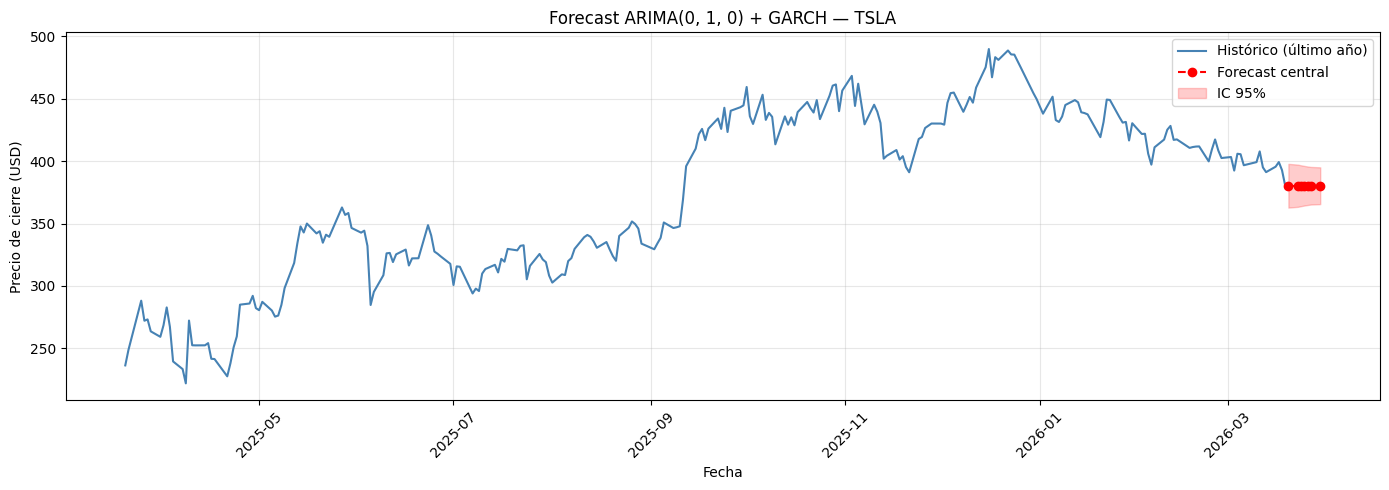


=== ESTADÍSTICAS DEL FORECAST — TSLA ===
Precio actual (último cierre): 380.30
Promedio predicho (7 días):    380.30
Desviación estándar:           0.00
Mínimo predicho:               380.30
Máximo predicho:               380.30
Potencial al alza:             0.00
Potencial a la baja:           -0.00

=== DECISIÓN DE INVERSIÓN — TSLA ===
Decisión: COMPRAR (BUY)

  ARIMA + GARCH — NVDA
Observaciones descargadas: 1056
Período: 2022-01-03 → 2026-03-19

Ajustando modelo ARIMA...
Mejor orden ARIMA encontrado: (3, 1, 1)

Generando forecast para los próximos 7 días hábiles...

=== FORECAST — NVDA (próximos 7 días hábiles) ===
           Fecha  Precio Predicho  Límite Inferior (95% CI)  Límite Superior (95% CI)
2026-03-20 (Fri)           178.87                    172.32                    185.43
2026-03-23 (Mon)           179.11                    173.00                    185.21
2026-03-24 (Tue)           179.58                    173.90                    185.26
2026-03-25 (Wed)           1

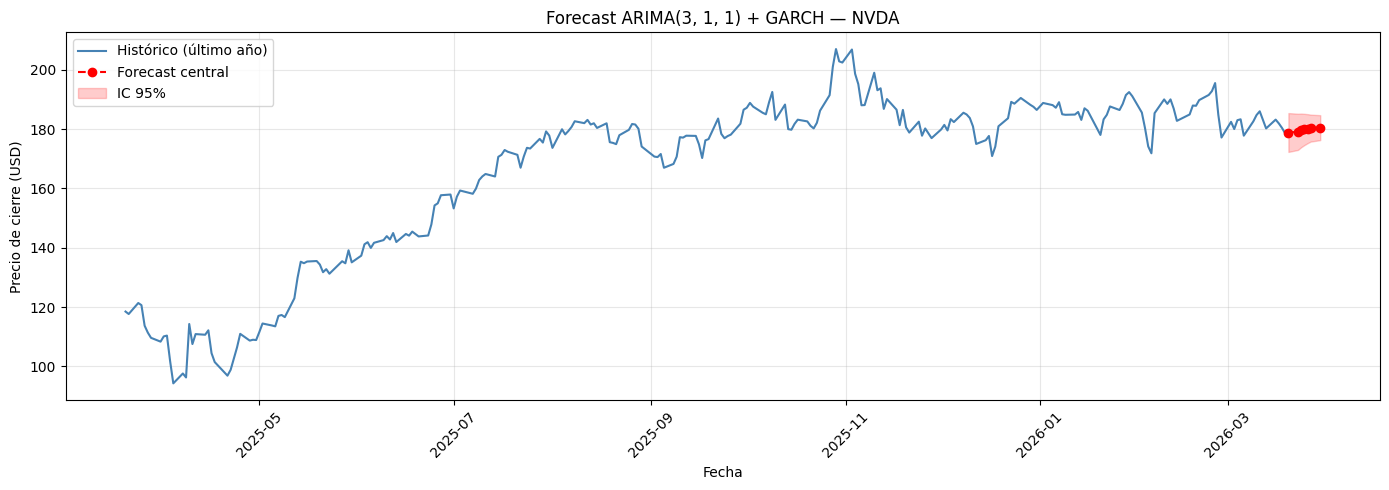


=== ESTADÍSTICAS DEL FORECAST — NVDA ===
Precio actual (último cierre): 178.56
Promedio predicho (7 días):    179.79
Desviación estándar:           0.58
Mínimo predicho:               178.87
Máximo predicho:               180.51
Potencial al alza:             1.95
Potencial a la baja:           -0.31

=== DECISIÓN DE INVERSIÓN — NVDA ===
Decisión: COMPRAR (BUY)

  ARIMA + GARCH — AMZN
Observaciones descargadas: 1056
Período: 2022-01-03 → 2026-03-19

Ajustando modelo ARIMA...
Mejor orden ARIMA encontrado: (0, 1, 0)

Generando forecast para los próximos 7 días hábiles...

=== FORECAST — AMZN (próximos 7 días hábiles) ===
           Fecha  Precio Predicho  Límite Inferior (95% CI)  Límite Superior (95% CI)
2026-03-20 (Fri)           208.76                    201.78                    215.73
2026-03-23 (Mon)           208.76                    202.82                    214.70
2026-03-24 (Tue)           208.76                    203.32                    214.20
2026-03-25 (Wed)           2

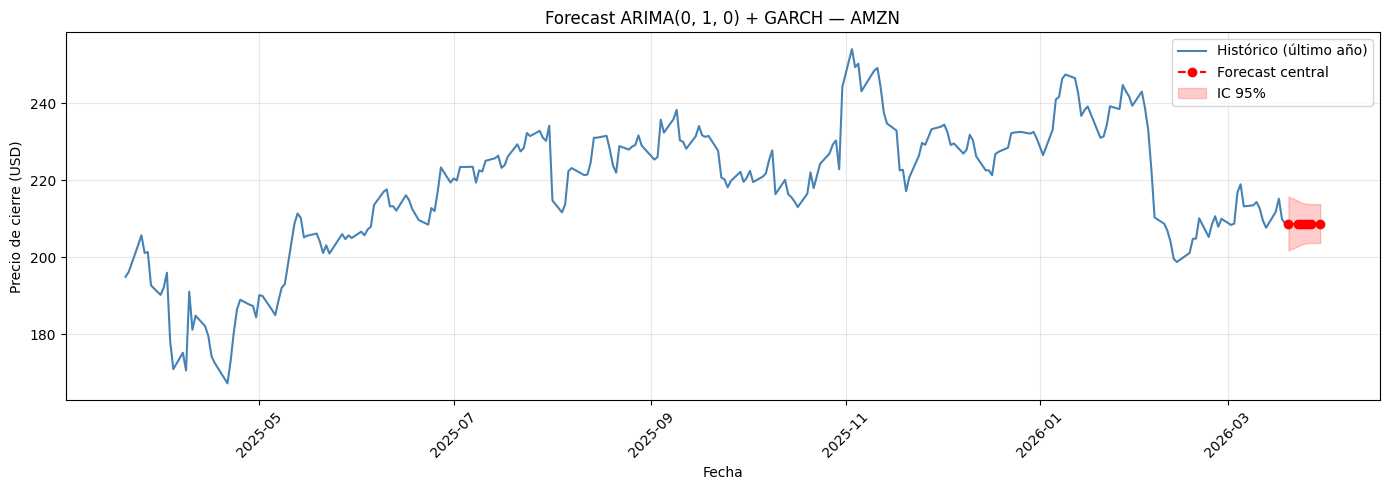


=== ESTADÍSTICAS DEL FORECAST — AMZN ===
Precio actual (último cierre): 208.76
Promedio predicho (7 días):    208.76
Desviación estándar:           0.00
Mínimo predicho:               208.76
Máximo predicho:               208.76
Potencial al alza:             0.00
Potencial a la baja:           -0.00

=== DECISIÓN DE INVERSIÓN — AMZN ===
Decisión: COMPRAR (BUY)

  ARIMA + GARCH — MSFT
Observaciones descargadas: 1056
Período: 2022-01-03 → 2026-03-19

Ajustando modelo ARIMA...
Mejor orden ARIMA encontrado: (0, 1, 0)

Generando forecast para los próximos 7 días hábiles...

=== FORECAST — MSFT (próximos 7 días hábiles) ===
           Fecha  Precio Predicho  Límite Inferior (95% CI)  Límite Superior (95% CI)
2026-03-20 (Fri)           389.02                    377.92                    400.12
2026-03-23 (Mon)           389.02                    378.12                    399.92
2026-03-24 (Tue)           389.02                    378.25                    399.79
2026-03-25 (Wed)           3

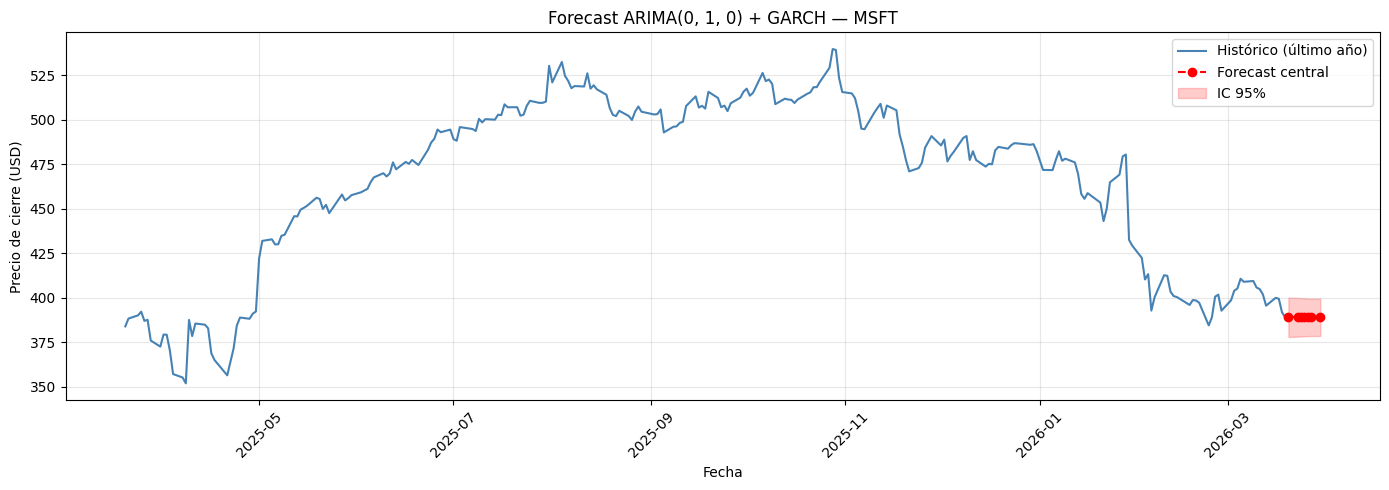


=== ESTADÍSTICAS DEL FORECAST — MSFT ===
Precio actual (último cierre): 389.02
Promedio predicho (7 días):    389.02
Desviación estándar:           0.00
Mínimo predicho:               389.02
Máximo predicho:               389.02
Potencial al alza:             0.00
Potencial a la baja:           -0.00

=== DECISIÓN DE INVERSIÓN — MSFT ===
Decisión: COMPRAR (BUY)

  ARIMA + GARCH — META
Observaciones descargadas: 1056
Período: 2022-01-03 → 2026-03-19

Ajustando modelo ARIMA...
Mejor orden ARIMA encontrado: (1, 1, 0)

Generando forecast para los próximos 7 días hábiles...

=== FORECAST — META (próximos 7 días hábiles) ===
           Fecha  Precio Predicho  Límite Inferior (95% CI)  Límite Superior (95% CI)
2026-03-20 (Fri)           607.21                    584.22                    630.19
2026-03-23 (Mon)           607.18                    585.51                    628.84
2026-03-24 (Tue)           607.18                    586.68                    627.68
2026-03-25 (Wed)           6

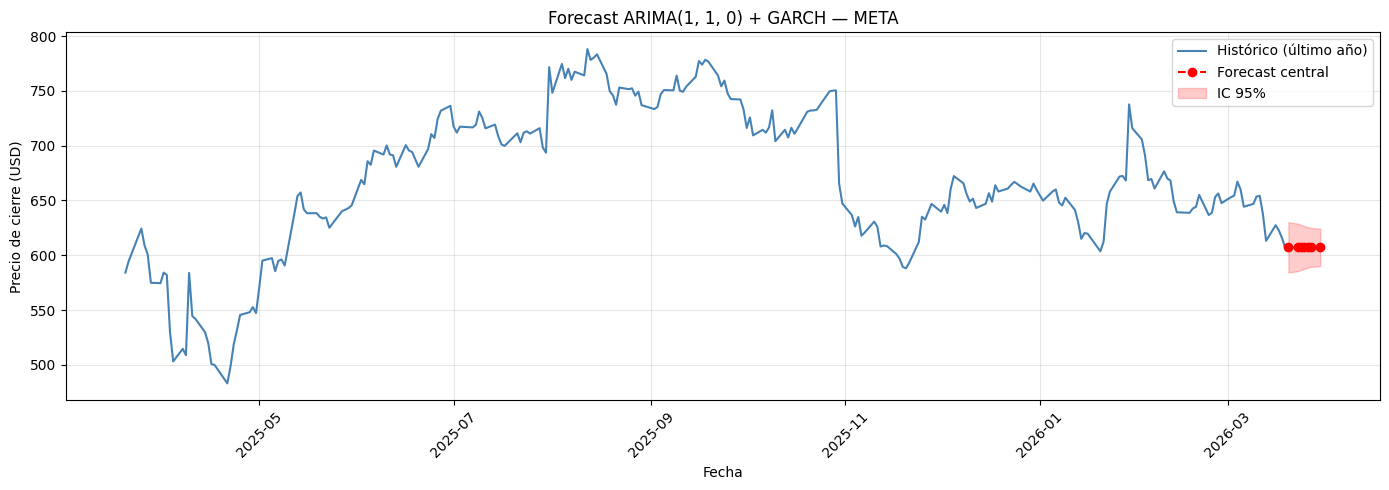


=== ESTADÍSTICAS DEL FORECAST — META ===
Precio actual (último cierre): 606.70
Promedio predicho (7 días):    607.18
Desviación estándar:           0.01
Mínimo predicho:               607.18
Máximo predicho:               607.21
Potencial al alza:             0.51
Potencial a la baja:           -0.48

=== DECISIÓN DE INVERSIÓN — META ===
Decisión: COMPRAR (BUY)

  ARIMA + GARCH — AAPL
Observaciones descargadas: 1056
Período: 2022-01-03 → 2026-03-19

Ajustando modelo ARIMA...
Mejor orden ARIMA encontrado: (1, 1, 0)

Generando forecast para los próximos 7 días hábiles...

=== FORECAST — AAPL (próximos 7 días hábiles) ===
           Fecha  Precio Predicho  Límite Inferior (95% CI)  Límite Superior (95% CI)
2026-03-20 (Fri)            248.9                    242.72                    255.09
2026-03-23 (Mon)            248.9                    243.05                    254.75
2026-03-24 (Tue)            248.9                    243.30                    254.50
2026-03-25 (Wed)            

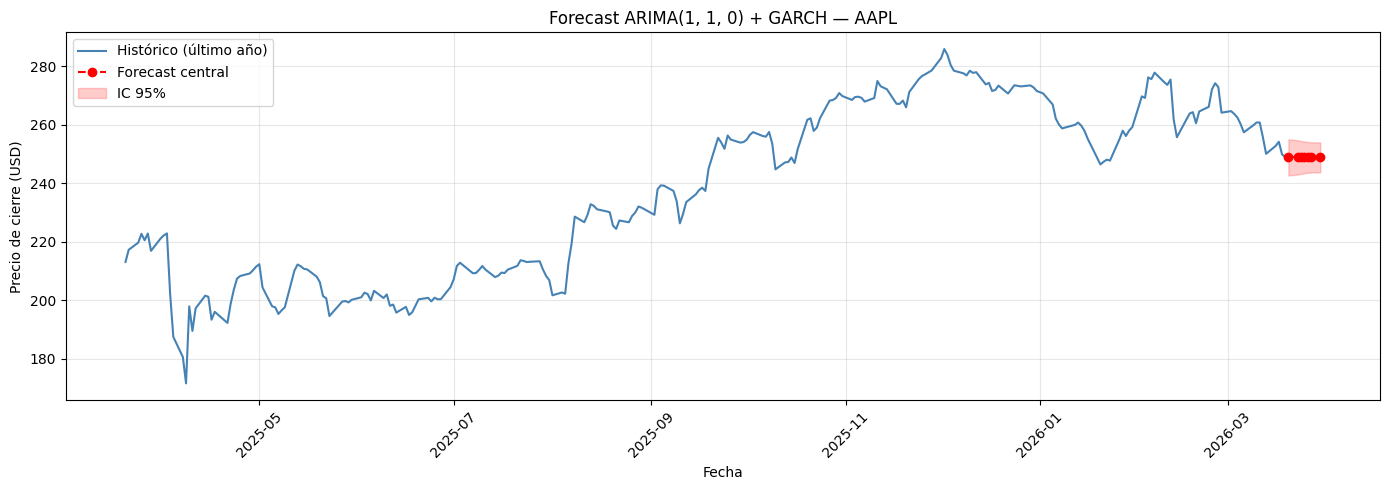


=== ESTADÍSTICAS DEL FORECAST — AAPL ===
Precio actual (último cierre): 248.96
Promedio predicho (7 días):    248.90
Desviación estándar:           0.00
Mínimo predicho:               248.90
Máximo predicho:               248.90
Potencial al alza:             -0.06
Potencial a la baja:           0.06

=== DECISIÓN DE INVERSIÓN — AAPL ===
Decisión: VENDER EN CORTO (SHORT)

  ARIMA + GARCH — QQQ
Observaciones descargadas: 1056
Período: 2022-01-03 → 2026-03-19

Ajustando modelo ARIMA...
Mejor orden ARIMA encontrado: (0, 1, 0)

Generando forecast para los próximos 7 días hábiles...

=== FORECAST — QQQ (próximos 7 días hábiles) ===
           Fecha  Precio Predicho  Límite Inferior (95% CI)  Límite Superior (95% CI)
2026-03-20 (Fri)           593.02                    581.99                    604.05
2026-03-23 (Mon)           593.02                    582.77                    603.27
2026-03-24 (Tue)           593.02                    583.40                    602.64
2026-03-25 (Wed)    

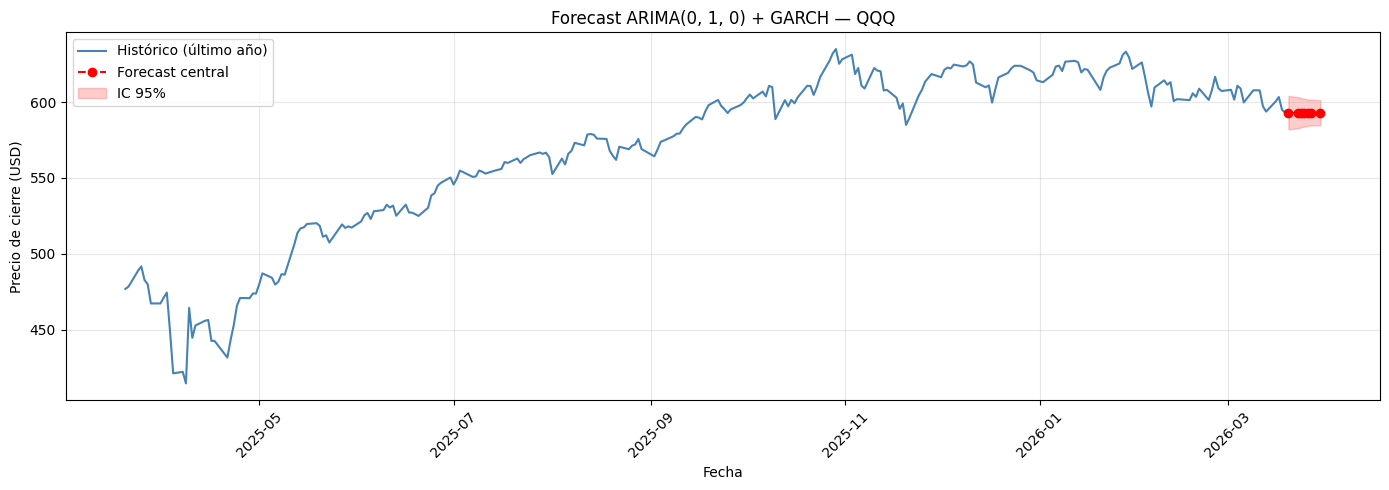


=== ESTADÍSTICAS DEL FORECAST — QQQ ===
Precio actual (último cierre): 593.02
Promedio predicho (7 días):    593.02
Desviación estándar:           0.00
Mínimo predicho:               593.02
Máximo predicho:               593.02
Potencial al alza:             -0.00
Potencial a la baja:           0.00

=== DECISIÓN DE INVERSIÓN — QQQ ===
Decisión: VENDER EN CORTO (SHORT)


In [16]:
# Activos seleccionados con base en el análisis econométrico de R:
# - Beta > 1 vs SPY (activos ofensivos con mayor sensibilidad al mercado)
# - Significancia estadística en la regresión múltiple
# - VIF aceptable (sin multicolinealidad severa individual)
tickers_arima = ['TSLA', 'NVDA', 'AMZN', 'MSFT', 'META', 'AAPL', 'QQQ']

# Se almacenan los resultados de cada activo para la tabla resumen final
resultados_arima = []

for ticker in tickers_arima:
    resultado = arima_forecast(ticker, start='2022-01-01', n_days=7)
    resultados_arima.append(resultado)

## Paso 5 — Tabla resumen de todos los forecasts

Se consolidan los resultados de los 7 modelos ARIMA en una sola tabla
comparativa. Esta tabla es el insumo principal para determinar los pesos
finales del portafolio en la Sección 2.11 del proyecto en R:
los activos con mayor potencial al alza y decisión COMPRAR recibirán
mayor peso en la asignación de capital.

TABLA RESUMEN — FORECAST ARIMA + GARCH (7 días hábiles)
Activo  Precio Actual  Promedio Forecast  Desv. Est.  Potencial Alza  Potencial Baja                Decisión Orden ARIMA
  TSLA     380.299988             380.30        0.00            0.00           -0.00           COMPRAR (BUY)   (0, 1, 0)
  NVDA     178.559998             179.79        0.58            1.95           -0.31           COMPRAR (BUY)   (3, 1, 1)
  AMZN     208.759995             208.76        0.00            0.00           -0.00           COMPRAR (BUY)   (0, 1, 0)
  MSFT     389.019989             389.02        0.00            0.00           -0.00           COMPRAR (BUY)   (0, 1, 0)
  META     606.700012             607.18        0.01            0.51           -0.48           COMPRAR (BUY)   (1, 1, 0)
  AAPL     248.960007             248.90        0.00           -0.06            0.06 VENDER EN CORTO (SHORT)   (1, 1, 0)
   QQQ     593.020020             593.02        0.00           -0.00            0.00 VENDER EN CO

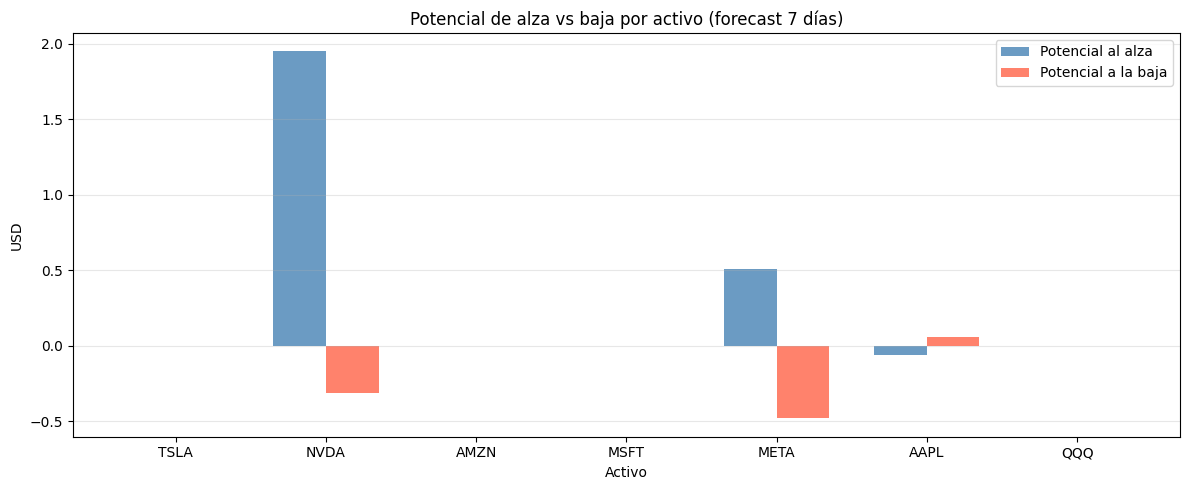

In [17]:
# Se construye la tabla resumen con todos los resultados
resumen_df = pd.DataFrame(resultados_arima)
resumen_df = resumen_df[[
    'ticker', 'current_price', 'avg_forecast', 'std_forecast',
    'potential_up', 'potential_down', 'decision', 'arima_order'
]]
resumen_df.columns = [
    'Activo', 'Precio Actual', 'Promedio Forecast',
    'Desv. Est.', 'Potencial Alza', 'Potencial Baja',
    'Decisión', 'Orden ARIMA'
]

print('='*80)
print('TABLA RESUMEN — FORECAST ARIMA + GARCH (7 días hábiles)')
print('='*80)
print(resumen_df.to_string(index=False))

# Gráfica de barras: potencial al alza vs a la baja por activo
fig, ax = plt.subplots(figsize=(12, 5))
x = np.arange(len(resumen_df))
width = 0.35
bars1 = ax.bar(x - width/2, resumen_df['Potencial Alza'],
               width, label='Potencial al alza', color='steelblue', alpha=0.8)
bars2 = ax.bar(x + width/2, resumen_df['Potencial Baja'],
               width, label='Potencial a la baja', color='tomato', alpha=0.8)
ax.set_xlabel('Activo')
ax.set_ylabel('USD')
ax.set_title('Potencial de alza vs baja por activo (forecast 7 días)')
ax.set_xticks(x)
ax.set_xticklabels(resumen_df['Activo'])
ax.legend()
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

---
# PARTE 2 — Panel Data con efectos fijos (PanelOLS)

El modelo de datos de panel permite analizar simultáneamente la relación
entre variables fundamentales y el desempeño financiero de múltiples
empresas a lo largo del tiempo. A diferencia de una regresión simple,
controla por las características fijas de cada empresa (efectos fijos)
que no cambian en el tiempo, como el sector, la cultura corporativa
o la posición competitiva.

**Variable dependiente:** Net Income (ingreso neto trimestral)

**Variables independientes:**
- `Revenue`: Ingresos totales trimestrales (USD millones)
- `OperatingMargin`: Margen operativo (%)
- `DebtToEquity`: Razón deuda/capital

**Empresas analizadas:** TSLA, NVDA, AMZN, MSFT, META, AAPL, QCOM

## Paso 6 — Construcción del dataset de Panel Data

Se descargan los datos financieros trimestrales de cada empresa usando
`yfinance`. Se extraen Revenue, OperatingMargin, DebtToEquity y
NetIncome de los estados financieros históricos disponibles.
Los datos se consolidan en un DataFrame con índice múltiple
(Ticker, Date), estructura requerida por `PanelOLS`.

In [18]:
# Activos para el Panel Data (mismos del portafolio, sin QQQ que es un ETF)
tickers_panel = ['TSLA', 'NVDA', 'AMZN', 'MSFT', 'META', 'AAPL', 'QCOM']

panel_records = []

for ticker in tickers_panel:
    print(f'Descargando datos fundamentales: {ticker}...')
    try:
        stock = yf.Ticker(ticker)

        # Se obtienen los estados financieros trimestrales
        # income_stmt contiene Revenue, OperatingIncome y NetIncome
        income = stock.quarterly_income_stmt
        balance = stock.quarterly_balance_sheet

        if income is None or income.empty:
            print(f'  Sin datos de income para {ticker}, omitiendo.')
            continue

        # Se extraen las variables necesarias
        for date in income.columns:
            try:
                revenue = income.loc['Total Revenue', date] / 1e6 \
                    if 'Total Revenue' in income.index else np.nan
                net_income = income.loc['Net Income', date] / 1e6 \
                    if 'Net Income' in income.index else np.nan
                op_income = income.loc['Operating Income', date] / 1e6 \
                    if 'Operating Income' in income.index else np.nan

                # Margen operativo = Operating Income / Revenue
                op_margin = (op_income / revenue * 100) \
                    if (revenue and revenue != 0) else np.nan

                # Debt-to-Equity del balance sheet
                debt_to_equity = np.nan
                if balance is not None and not balance.empty and date in balance.columns:
                    total_debt = balance.loc['Total Debt', date] / 1e6 \
                        if 'Total Debt' in balance.index else np.nan
                    equity = balance.loc['Stockholders Equity', date] / 1e6 \
                        if 'Stockholders Equity' in balance.index else np.nan
                    if equity and equity != 0:
                        debt_to_equity = total_debt / equity

                panel_records.append({
                    'Ticker': ticker,
                    'Date': pd.to_datetime(date),
                    'Revenue': revenue,
                    'NetIncome': net_income,
                    'OperatingMargin': op_margin,
                    'DebtToEquity': debt_to_equity
                })
            except Exception:
                continue
    except Exception as e:
        print(f'  Error en {ticker}: {e}')
        continue

# Se construye el DataFrame del panel
panel_df = pd.DataFrame(panel_records)
panel_df = panel_df.dropna()
panel_df = panel_df.set_index(['Ticker', 'Date'])
panel_df = panel_df.sort_index()

print(f'\nDataset de panel construido correctamente.')
print(f'Observaciones totales: {len(panel_df)}')
print(f'Empresas: {panel_df.index.get_level_values("Ticker").unique().tolist()}')
print(f'\nPrimeras filas:')
print(panel_df.head(10))

Descargando datos fundamentales: TSLA...
Descargando datos fundamentales: NVDA...
Descargando datos fundamentales: AMZN...
Descargando datos fundamentales: MSFT...
Descargando datos fundamentales: META...
Descargando datos fundamentales: AAPL...
Descargando datos fundamentales: QCOM...

Dataset de panel construido correctamente.
Observaciones totales: 35
Empresas: ['AAPL', 'AMZN', 'META', 'MSFT', 'NVDA', 'QCOM', 'TSLA']

Primeras filas:
                    Revenue  NetIncome  OperatingMargin  DebtToEquity
Ticker Date                                                          
AAPL   2024-12-31  124300.0    36330.0        34.458568      1.449999
       2025-03-31   95359.0    24780.0        31.029059      1.469938
       2025-06-30   94036.0    23434.0        29.990642      1.544858
       2025-09-30  102466.0    27466.0        31.646595      1.338030
       2025-12-31  143756.0    42097.0        35.373828      1.026295
AMZN   2024-12-31  187792.0    20004.0        11.290683      0.457740

## Paso 7 — Estadísticas descriptivas del panel

Antes de correr el modelo, se revisan las estadísticas descriptivas
del dataset para identificar posibles outliers o valores inconsistentes
en las variables fundamentales.

=== ESTADÍSTICAS DESCRIPTIVAS DEL PANEL ===
         Revenue  NetIncome  OperatingMargin  DebtToEquity
count      35.00      35.00            35.00         35.00
mean    72040.20   18093.09            32.25          0.44
std     55973.45   12994.42            18.48          0.42
min     10365.00   -3117.00             2.55          0.07
25%     26901.00    2908.00            11.76          0.17
50%     57006.00   20838.00            31.65          0.27
75%     94697.50   26123.00            45.56          0.53
max    213386.00   42960.00            65.02          1.54


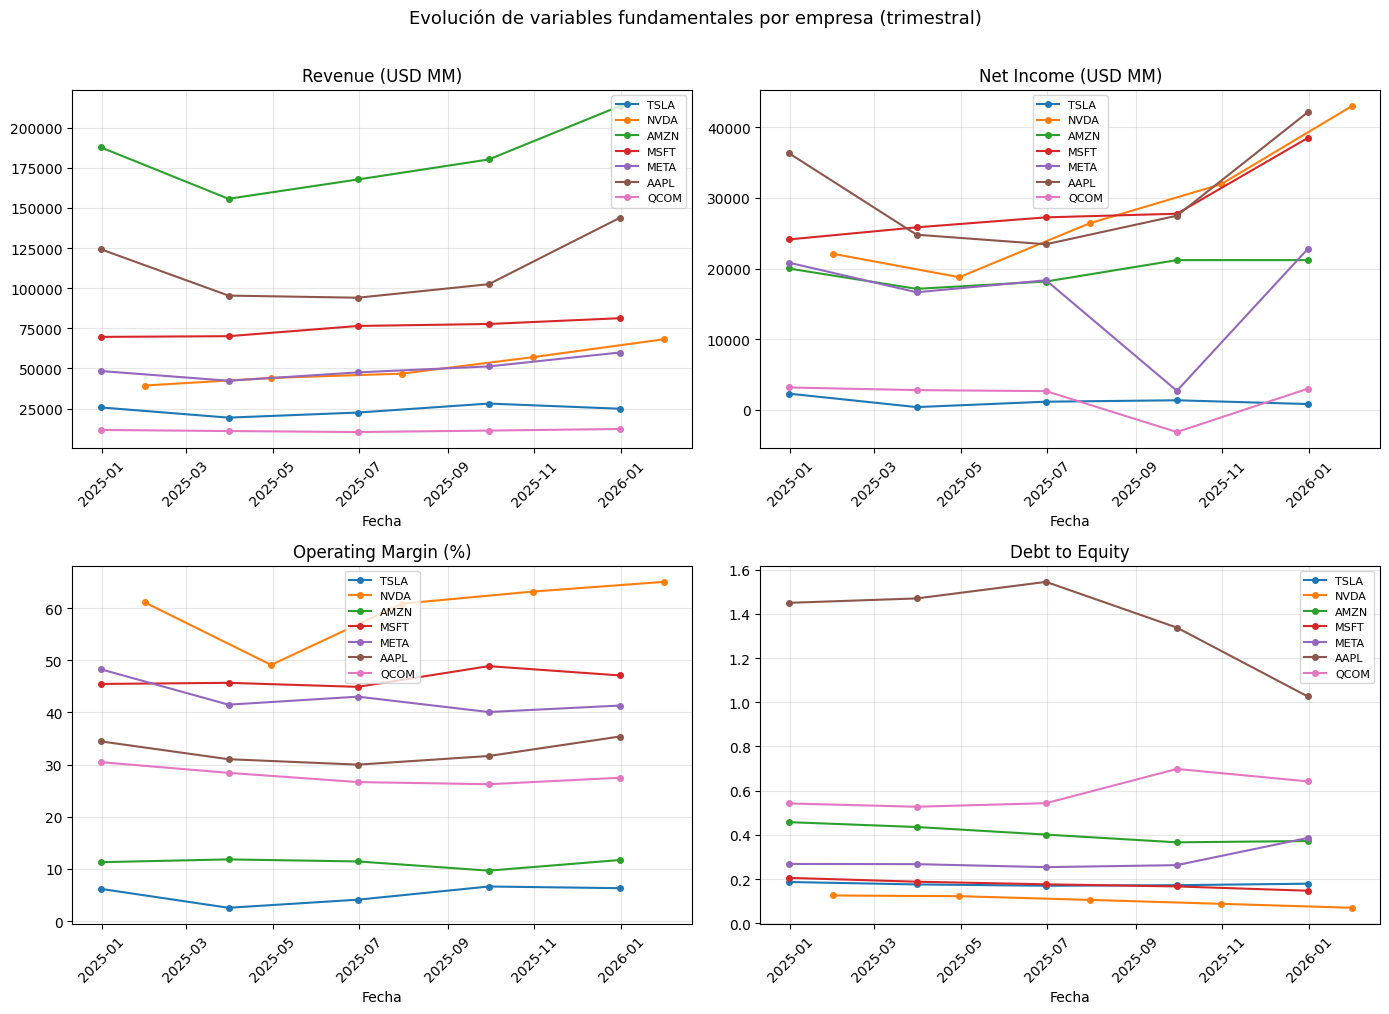

In [19]:
print('=== ESTADÍSTICAS DESCRIPTIVAS DEL PANEL ===')
print(panel_df.describe().round(2))

# Gráfica de evolución de Revenue por empresa
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

variables = ['Revenue', 'NetIncome', 'OperatingMargin', 'DebtToEquity']
titulos   = ['Revenue (USD MM)', 'Net Income (USD MM)',
             'Operating Margin (%)', 'Debt to Equity']

for ax, var, titulo in zip(axes.flatten(), variables, titulos):
    for ticker in tickers_panel:
        try:
            datos = panel_df.loc[ticker, var]
            ax.plot(datos.index, datos.values, marker='o',
                    markersize=4, label=ticker)
        except Exception:
            continue
    ax.set_title(titulo)
    ax.set_xlabel('Fecha')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)
    ax.tick_params(axis='x', rotation=45)

plt.suptitle('Evolución de variables fundamentales por empresa (trimestral)',
             fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

## Paso 8 — Modelo de datos de panel con efectos fijos (PanelOLS)

Se estima el modelo PanelOLS con efectos fijos por entidad (empresa).
Los efectos fijos controlan por características no observables de cada
empresa que son constantes en el tiempo (modelo de negocio, posición
competitiva, etc.), permitiendo identificar el efecto puro de las
variables fundamentales sobre el Net Income.

In [20]:
# Se preparan las variables del modelo
# X: Revenue, OperatingMargin, DebtToEquity (variables independientes)
# y: NetIncome (variable dependiente)
X_panel = add_constant(
    panel_df[['Revenue', 'OperatingMargin', 'DebtToEquity']].dropna()
)
y_panel = panel_df['NetIncome'].dropna()

# Se alinean los índices para que X e y tengan exactamente las mismas obs.
idx = X_panel.index.intersection(y_panel.index)
X_panel = X_panel.loc[idx]
y_panel = y_panel.loc[idx]

print(f'Observaciones en el modelo: {len(y_panel)}')

# Se estima el modelo PanelOLS con efectos fijos por entidad
# entity_effects=True controla por las características fijas de cada empresa
modelo_panel = PanelOLS(
    y_panel, X_panel,
    entity_effects=True
)
resultado_panel = modelo_panel.fit()
print(resultado_panel.summary)

Observaciones en el modelo: 35
                          PanelOLS Estimation Summary                           
Dep. Variable:              NetIncome   R-squared:                        0.5981
Estimator:                   PanelOLS   R-squared (Between):              0.3208
No. Observations:                  35   R-squared (Within):               0.5981
Date:                Fri, Mar 20 2026   R-squared (Overall):              0.3712
Time:                        05:41:12   Log-likelihood                   -334.91
Cov. Estimator:            Unadjusted                                           
                                        F-statistic:                      12.402
Entities:                           7   P-value                           0.0000
Avg Obs:                       5.0000   Distribution:                    F(3,25)
Min Obs:                       5.0000                                           
Max Obs:                       5.0000   F-statistic (robust):             12.4

## Paso 9 — Visualización de resultados del Panel Data

Se grafican los coeficientes del modelo con sus intervalos de confianza
y los valores reales vs predichos de Net Income para evaluar
el ajuste del modelo.

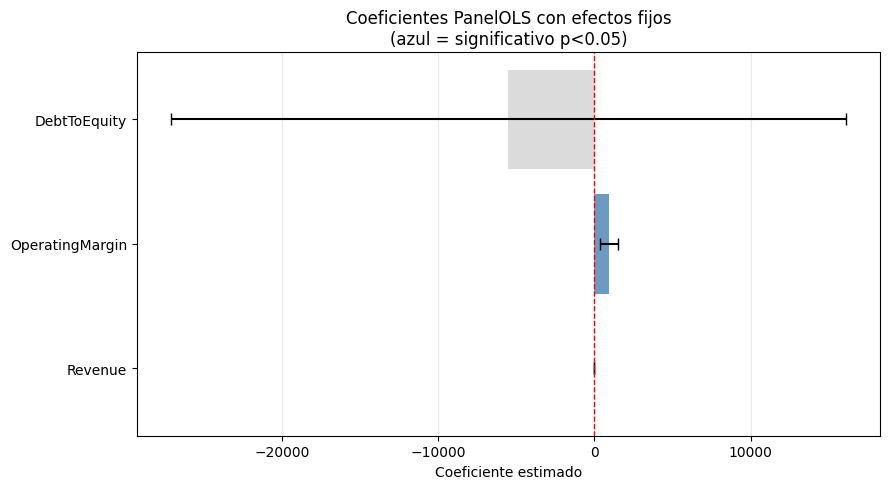

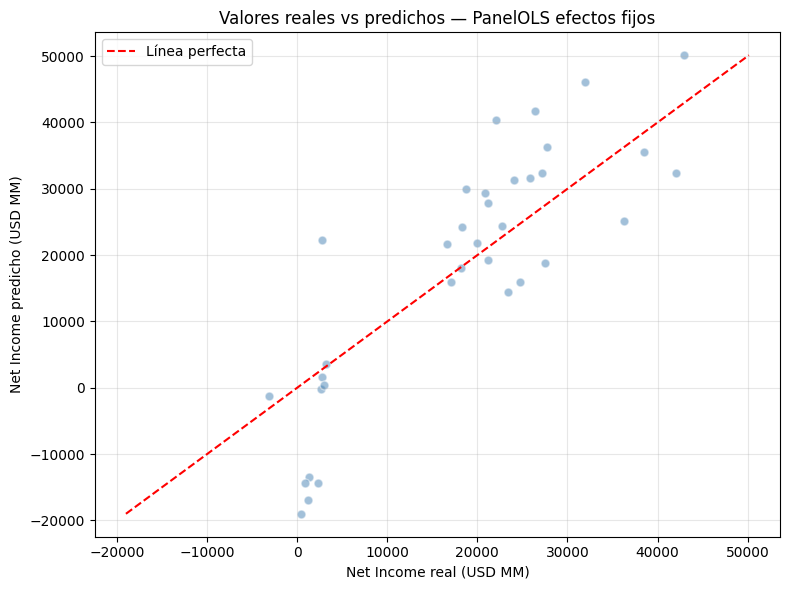


=== RESUMEN DE SIGNIFICANCIA ===
Revenue             : coef =     0.2024 | *** (p<0.01)
OperatingMargin     : coef =   939.2281 | *** (p<0.01)
DebtToEquity        : coef = -5497.9902 | No significativo


In [21]:
# Gráfica 1: Coeficientes con intervalos de confianza
params  = resultado_panel.params.drop('const', errors='ignore')
ci_low  = resultado_panel.conf_int()['lower'].drop('const', errors='ignore')
ci_high = resultado_panel.conf_int()['upper'].drop('const', errors='ignore')
pvals   = resultado_panel.pvalues.drop('const', errors='ignore')

fig, ax = plt.subplots(figsize=(9, 5))
colors = ['steelblue' if p < 0.05 else 'lightgray' for p in pvals]
ax.barh(params.index, params.values, color=colors, alpha=0.8)
ax.errorbar(
    params.values, params.index,
    xerr=[params.values - ci_low.values, ci_high.values - params.values],
    fmt='none', color='black', capsize=4
)
ax.axvline(0, color='red', linestyle='--', linewidth=1)
ax.set_title('Coeficientes PanelOLS con efectos fijos\n(azul = significativo p<0.05)')
ax.set_xlabel('Coeficiente estimado')
ax.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.show()

# Gráfica 2: Valores reales vs predichos
fitted  = resultado_panel.fitted_values
actual  = y_panel.loc[fitted.index]

plt.figure(figsize=(8, 6))
plt.scatter(actual, fitted, alpha=0.5, color='steelblue', edgecolors='white', s=40)
lim_min = min(actual.min(), fitted['fitted_values'].min())
lim_max = max(actual.max(), fitted['fitted_values'].max())
plt.plot([lim_min, lim_max], [lim_min, lim_max],
         'r--', linewidth=1.5, label='Línea perfecta')
plt.xlabel('Net Income real (USD MM)')
plt.ylabel('Net Income predicho (USD MM)')
plt.title('Valores reales vs predichos — PanelOLS efectos fijos')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Resumen de significancia
print('\n=== RESUMEN DE SIGNIFICANCIA ===')
for var in params.index:
    sig = '*** (p<0.01)' if pvals[var] < 0.01 else \
          '**  (p<0.05)' if pvals[var] < 0.05 else \
          '*   (p<0.10)' if pvals[var] < 0.10 else \
          'No significativo'
    print(f'{var:20s}: coef = {params[var]:10.4f} | {sig}')

---
# PARTE 3 — Conclusión: Pesos finales del portafolio

Con base en los resultados del ARIMA + GARCH (potencial al alza,
decisión de inversión) y los modelos econométricos de R (beta vs SPY,
VIF, Durbin-Watson), se determina la asignación final de capital
para los $100,000,000 USD del portafolio.

Los pesos se asignan priorizando:
1. Activos con decisión **COMPRAR** en el ARIMA
2. Mayor potencial al alza relativo
3. Beta adecuado al perfil ofensivo/defensivo del portafolio

In [22]:
# Tabla final de decisiones de inversión combinando ARIMA + análisis de R
print('='*70)
print('RESUMEN FINAL — DECISIONES DE INVERSIÓN')
print('(Integra resultados ARIMA + econometría de R)')
print('='*70)

for r in resultados_arima:
    retorno_esp = (r['avg_forecast'] - r['current_price']) / r['current_price'] * 100
    print(f"\n{r['ticker']:6s} | Precio actual: ${r['current_price']:8.2f} "
          f"| Forecast promedio: ${r['avg_forecast']:8.2f} "
          f"| Retorno esperado: {retorno_esp:+.2f}% "
          f"| {r['decision']}")

print('\n' + '='*70)
print('Nota: usar estos resultados junto con los betas de R para')
print('definir los pesos finales en la Sección 2.11 del proyecto.')
print('='*70)

RESUMEN FINAL — DECISIONES DE INVERSIÓN
(Integra resultados ARIMA + econometría de R)

TSLA   | Precio actual: $  380.30 | Forecast promedio: $  380.30 | Retorno esperado: +0.00% | COMPRAR (BUY)

NVDA   | Precio actual: $  178.56 | Forecast promedio: $  179.79 | Retorno esperado: +0.69% | COMPRAR (BUY)

AMZN   | Precio actual: $  208.76 | Forecast promedio: $  208.76 | Retorno esperado: +0.00% | COMPRAR (BUY)

MSFT   | Precio actual: $  389.02 | Forecast promedio: $  389.02 | Retorno esperado: +0.00% | COMPRAR (BUY)

META   | Precio actual: $  606.70 | Forecast promedio: $  607.18 | Retorno esperado: +0.08% | COMPRAR (BUY)

AAPL   | Precio actual: $  248.96 | Forecast promedio: $  248.90 | Retorno esperado: -0.02% | VENDER EN CORTO (SHORT)

QQQ    | Precio actual: $  593.02 | Forecast promedio: $  593.02 | Retorno esperado: -0.00% | VENDER EN CORTO (SHORT)

Nota: usar estos resultados junto con los betas de R para
definir los pesos finales en la Sección 2.11 del proyecto.
